In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Parameters
x_start, x_end = 0, 2
h_range = np.arange(0.01, 1.01, 0.05)

baseline_x = None
baseline_y = None

#Function
def f(x, y):
    return -2 * y

--- Run h=0.01: Baseline Run (First Run) ---

--- Run h=0.06 ---
x: 0.00 | Error: 0.000000
x: 0.06 | Error: 0.005981
x: 0.12 | Error: 0.010546
x: 0.18 | Error: 0.013948
x: 0.24 | Error: 0.016397
x: 0.30 | Error: 0.018071
x: 0.36 | Error: 0.019120
x: 0.42 | Error: 0.019667
x: 0.48 | Error: 0.019818
x: 0.55 | Error: 0.019658
x: 0.61 | Error: 0.019258
x: 0.67 | Error: 0.018678
x: 0.73 | Error: 0.017965
x: 0.79 | Error: 0.017160
x: 0.85 | Error: 0.016294
x: 0.91 | Error: 0.015393
x: 0.97 | Error: 0.014477
x: 1.03 | Error: 0.013564
x: 1.09 | Error: 0.012666
x: 1.15 | Error: 0.011791
x: 1.21 | Error: 0.010945
x: 1.27 | Error: 0.010135
x: 1.33 | Error: 0.009363
x: 1.39 | Error: 0.008632
x: 1.45 | Error: 0.007943
x: 1.52 | Error: 0.007297
x: 1.58 | Error: 0.006692
x: 1.64 | Error: 0.006128
x: 1.70 | Error: 0.005604
x: 1.76 | Error: 0.005118
x: 1.82 | Error: 0.004669
x: 1.88 | Error: 0.004255
x: 1.94 | Error: 0.003873
x: 2.00 | Error: 0.003522
Total Accumulated Error: 0.3946

--- Run h=0.11 ---

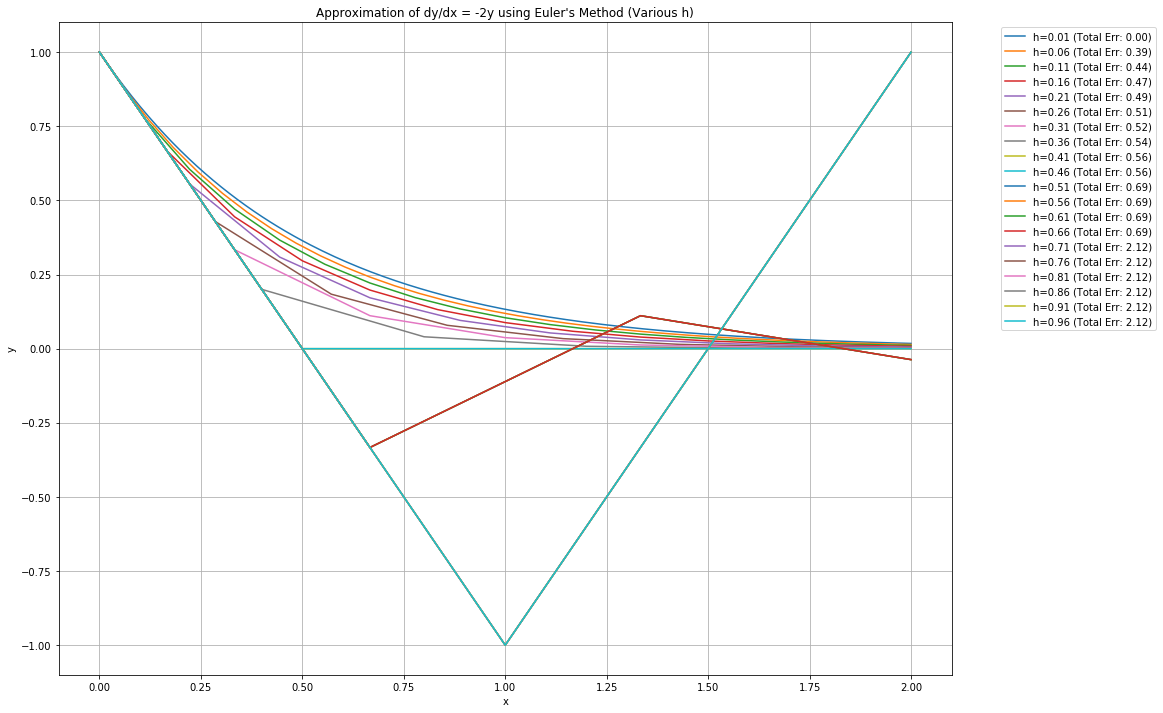

In [2]:
plt.figure(figsize=(16, 12))

for h_step in h_range:
    h = h_step  
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1

    # Euler's method
    h_actual = x_values[1] - x_values[0] if num_steps > 0 else h
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h_actual * f(x_values[i], y_values[i])

    #Error calculation
    if baseline_y is None:
        baseline_x = x_values
        baseline_y = y_values
        total_error = 0
        print(f"--- Run h={h:.2f}: Baseline Run (First Run) ---\n")
    else:
        # 1. Error for each point (Current run vs First run)
        # Interpolate baseline to match current x_values
        y_baseline_interp = np.interp(x_values, baseline_x, baseline_y)
        point_errors = np.abs(y_values - y_baseline_interp)
        
        # 2. Total accumulated error for the run
        total_error = np.sum(point_errors)

        print(f"--- Run h={h:.2f} ---")
        for j in range(len(x_values)):
            print(f"x: {x_values[j]:.2f} | Error: {point_errors[j]:.6f}")
        print(f"Total Accumulated Error: {total_error:.4f}\n")

    #plot each run
    plt.plot(x_values, y_values, label=f"h={h:.2f} (Total Err: {total_error:.2f})")

#Graphing
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method (Various h)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()